# Reddit Mental-Health Discussions: NLP Analysis (2019-2022)

This project analyzes Reddit posts from five mental-health communities between 2019 and 2022:
anxiety, depression, loneliness, mental health, and SuicideWatch.

The goal is to understand how discussion volume, sentiment, language, and community-level signals differ across communities and over time. The workflow preserves the raw files unchanged, uses a transparent row cap for reviewable runtime, and applies reproducible samples for heavier NLP tasks.

## 1. Imports and Settings

In [1]:
from pathlib import Path
import re
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import FeatureUnion, make_pipeline
from sklearn.svm import LinearSVC
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

In [2]:
warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_colwidth", 90)
sns.set_theme(style="whitegrid", context="notebook")

RANDOM_STATE = 42
ROWS_PER_FILE = 1_000
NLP_SAMPLE_SIZE = 10_000
MODEL_ROWS_PER_CLASS = 2_500

In [3]:
ROOT = Path.cwd()
RAW_DIRS = [ROOT / str(year) for year in range(2019, 2023)]
FACTOR_ORDER = ["anxiety", "depression", "loneliness", "mental health", "suicide watch"]
PALETTE = dict(zip(FACTOR_ORDER, sns.color_palette("Set2", n_colors=len(FACTOR_ORDER))))

## 2. Data Loading

The raw files are monthly Reddit exports stored in year folders. I preserve those files unchanged and build the analysis dataset in memory. By default, the notebook reads up to 1,000 rows from each CSV so it remains fast to review; set `ROWS_PER_FILE = None` to run on the full raw files.

In [4]:
MONTHS = {
    "jan": 1, "january": 1, "feb": 2, "february": 2, "mar": 3, "march": 3,
    "apr": 4, "april": 4, "may": 5, "jun": 6, "june": 6, "jul": 7, "july": 7,
    "aug": 8, "sep": 9, "sept": 9, "oct": 10, "nov": 11, "dec": 12,
}
FACTOR_MAP = {
    "anxiety": "anxiety", "depression": "depression", "lonely": "loneliness",
    "mentalhealth": "mental health", "suicidewatch": "suicide watch",
}

In [5]:
def read_csv(path, nrows=ROWS_PER_FILE):
    columns = {"title", "selftext", "subreddit", "created_utc", "timestamp", "score"}
    for encoding in ("utf-8", "latin1", "cp1252"):
        try:
            return pd.read_csv(path, encoding=encoding, dtype=str, nrows=nrows,
                               on_bad_lines="skip", usecols=lambda c: c.lower().strip() in columns)
        except UnicodeDecodeError:
            continue
    return pd.DataFrame()

In [6]:
def value_from_path(path, lookup):
    path_text = " ".join(part.lower() for part in path.parts)
    return next((value for key, value in lookup.items() if key in path_text), None)

csv_files = sorted(path for folder in RAW_DIRS for path in folder.rglob("*.csv"))
len(csv_files)

219

In [7]:
frames = []
for path in csv_files:
    part = read_csv(path)
    if part.empty:
        continue
    part.columns = part.columns.str.lower().str.strip()
    part["source_file"] = str(path.relative_to(ROOT))
    part["file_year"] = int(re.search(r"20(19|20|21|22)", str(path)).group())
    part["file_month"] = value_from_path(path, MONTHS)
    frames.append(part)

raw = pd.concat(frames, ignore_index=True)
raw.shape

(219000, 9)

## 3. Cleaning and Feature Preparation

Cleaning focuses on analysis-ready structure first: dates, communities, scores, and usable post text. Heavier text normalization and duplicate removal are applied inside the NLP samples where they are needed.

In [8]:
TOKEN_STOPWORDS = {
    "amp", "x200b", "deleted", "removed", "nan", "none", "null",
    "im", "ive", "id", "ill", "youre", "youve", "youll",
    "dont", "doesnt", "didnt", "cant", "couldnt", "wouldnt", "shouldnt",
    "isnt", "arent", "wasnt", "werent", "hasnt", "havent", "hadnt",
    "ve", "re", "ll", "don", "didn", "doesn", "isn", "wasn", "weren",
    "couldn", "wouldn", "shouldn", "hasn", "haven", "hadn", "ca",
}

In [9]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|&\w+;", " ", text)
    text = re.sub(r"n['’]t\b", " not", text)
    text = re.sub(r"['’](re|ve|ll|d|m|s|t)\b", " ", text)
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    tokens = [w for w in text.split() if w not in TOKEN_STOPWORDS and len(w) > 1]
    return " ".join(tokens)

In [10]:
df = raw.copy()
df["created_at"] = pd.to_datetime(pd.to_numeric(df["created_utc"], errors="coerce"), unit="s", errors="coerce")
df["year"] = df["created_at"].dt.year.fillna(df["file_year"]).astype("Int64")
df["month"] = df["created_at"].dt.month.fillna(df["file_month"]).astype("Int64")
df["factor"] = df["subreddit"].str.lower().str.replace(r"[^a-z]", "", regex=True).map(FACTOR_MAP)
df["score"] = pd.to_numeric(df.get("score"), errors="coerce")
df["raw_text"] = df["title"].fillna("") + " " + df["selftext"].fillna("")

In [11]:
df = df[df["year"].between(2019, 2022) & df["factor"].isin(FACTOR_ORDER)]
df = df[df["raw_text"].str.len().between(30, 10000)]
df["period"] = pd.to_datetime(dict(year=df["year"].astype(int), month=df["month"].astype(int), day=1))

columns = ["created_at", "period", "year", "month", "factor", "score", "raw_text", "source_file"]
df = df[columns].copy()
df.shape

(213838, 8)

In [12]:
coverage = pd.DataFrame({
    "metric": ["loaded rows", "analysis rows", "csv files", "date range", "communities"],
    "value": [
        f"{len(raw):,}",
        f"{len(df):,}",
        f"{len(csv_files):,}",
        f"{df['period'].min():%b %Y} to {df['period'].max():%b %Y}",
        df["factor"].nunique(),
    ],
})
coverage

,metric,value
0,loaded rows,"219,000"
1,analysis rows,"213,838"
2,csv files,219
3,date range,Jan 2019 to Aug 2022
4,communities,5


## 4. Exploratory Analysis

These plots show where the dataset is concentrated and how discussion volume changes across communities.

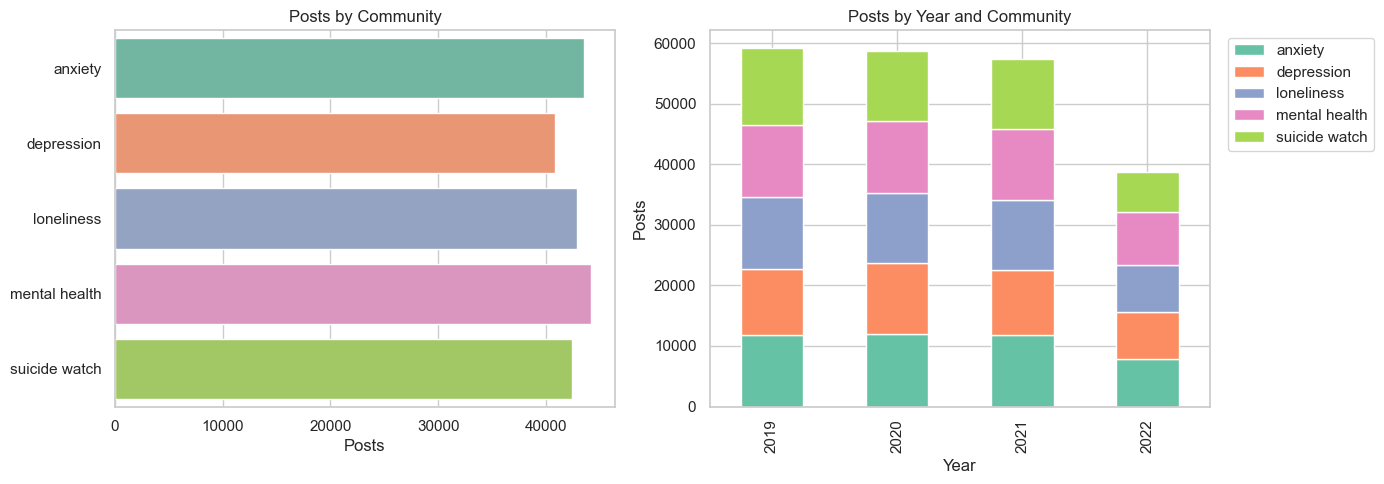

In [13]:
posts_by_factor = df["factor"].value_counts().reindex(FACTOR_ORDER)
posts_by_year = df.groupby(["year", "factor"]).size().unstack(fill_value=0)[FACTOR_ORDER]
monthly = df.groupby(["period", "factor"]).size().reset_index(name="posts")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x=posts_by_factor.values, y=posts_by_factor.index, ax=axes[0], palette=PALETTE)
axes[0].set(title="Posts by Community", xlabel="Posts", ylabel="")
posts_by_year.plot(kind="bar", stacked=True, ax=axes[1], color=[PALETTE[x] for x in FACTOR_ORDER])
axes[1].set(title="Posts by Year and Community", xlabel="Year", ylabel="Posts")
axes[1].legend(title="", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

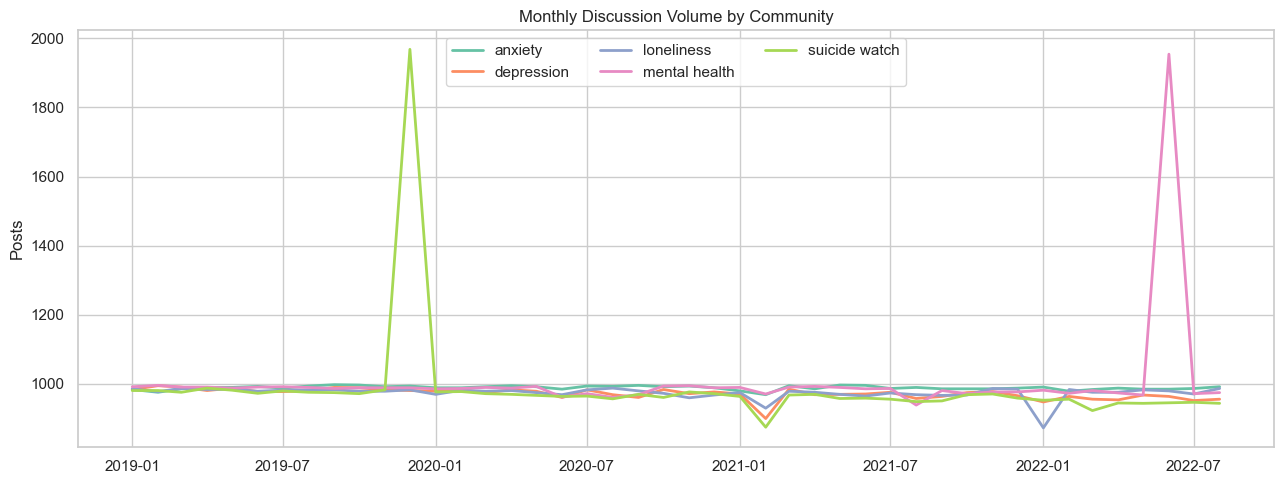

In [14]:
plt.figure(figsize=(13, 5))
sns.lineplot(data=monthly, x="period", y="posts", hue="factor", hue_order=FACTOR_ORDER,
             palette=PALETTE, linewidth=2)
plt.title("Monthly Discussion Volume by Community")
plt.xlabel("")
plt.ylabel("Posts")
plt.legend(title="", ncol=3)
plt.tight_layout()

In [15]:
text_sample = df.sample(min(len(df), 50_000), random_state=RANDOM_STATE).copy()
text_sample["word_count"] = text_sample["raw_text"].str.split().str.len()

length_summary = text_sample.groupby("factor").agg(
    sample_posts=("raw_text", "size"),
    median_words=("word_count", "median"),
    mean_words=("word_count", "mean"),
    median_score=("score", "median"),
).reindex(FACTOR_ORDER).round(1)
length_summary

,sample_posts,median_words,mean_words,median_score
factor,,,,
anxiety,10163,113.0,155.6,1.0
depression,9561,100.0,157.5,1.0
loneliness,10002,81.0,127.3,1.0
mental health,10384,145.0,210.0,1.0
suicide watch,9890,91.0,148.0,1.0


## 5. Sentiment Analysis

VADER is used because it is designed for short, informal social-media text. Sentiment is estimated on a stratified sample to keep the notebook fast while preserving year/community coverage.

In [16]:
nlp_sample = (
    df.groupby(["factor", "year"], group_keys=False)
      .apply(lambda x: x.sample(min(len(x), max(500, NLP_SAMPLE_SIZE // 20)), random_state=RANDOM_STATE))
      .sample(frac=1, random_state=RANDOM_STATE)
)
nlp_sample = nlp_sample.sample(min(len(nlp_sample), NLP_SAMPLE_SIZE), random_state=RANDOM_STATE)
nlp_sample["text"] = nlp_sample["raw_text"].map(clean_text)
nlp_sample = nlp_sample[nlp_sample["text"].str.len() >= 30].drop_duplicates(["text", "factor"])
nlp_sample.shape

(9766, 9)

In [17]:
analyzer = SentimentIntensityAnalyzer()
nlp_sample["sentiment"] = nlp_sample["text"].str.slice(0, 3000).map(
    lambda text: analyzer.polarity_scores(text)["compound"]
)

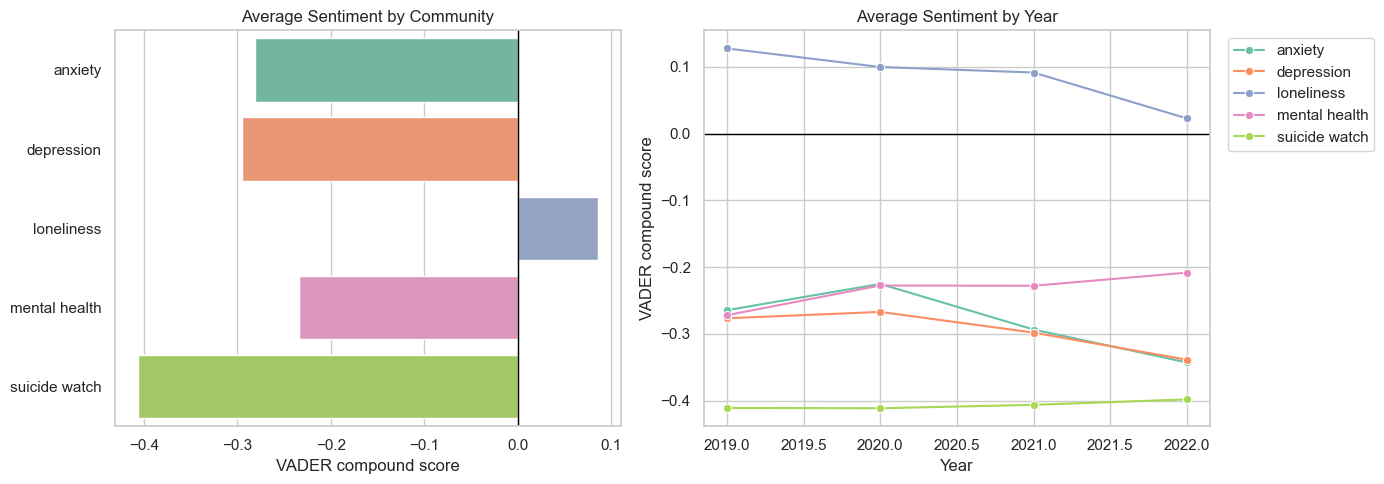

In [18]:
sentiment_factor = nlp_sample.groupby("factor")["sentiment"].mean().reindex(FACTOR_ORDER)
sentiment_year = nlp_sample.groupby(["year", "factor"])["sentiment"].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x=sentiment_factor.values, y=sentiment_factor.index, ax=axes[0], palette=PALETTE)
axes[0].axvline(0, color="black", linewidth=1)
axes[0].set(title="Average Sentiment by Community", xlabel="VADER compound score", ylabel="")
sns.lineplot(data=sentiment_year, x="year", y="sentiment", hue="factor",
             hue_order=FACTOR_ORDER, marker="o", palette=PALETTE, ax=axes[1])
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set(title="Average Sentiment by Year", xlabel="Year", ylabel="VADER compound score")
axes[1].legend(title="", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

## 6. TF-IDF Term Analysis

TF-IDF highlights language that is unusually important inside each community. Generic Reddit and mental-health terms are removed so the results focus on more meaningful differences.

In [19]:
DOMAIN_STOPWORDS = {
    "reddit", "subreddit", "post", "posts", "feel", "feeling", "felt",
    "just", "really", "like", "know", "want", "need", "help",
    "time", "people", "person", "thing", "things", "life",
    "go", "going", "went", "get", "got", "getting", "did", "does", "doing",
    "think", "thought", "day", "days", "having", "make", "way", "good", "bad",
    "year", "years", "anxiety", "anxious", "depression", "depressed",
    "lonely", "loneliness", "mental", "health", "suicide", "suicidal", "watch",
}
STOPWORDS = sorted(ENGLISH_STOP_WORDS.union(DOMAIN_STOPWORDS, TOKEN_STOPWORDS))
TOKEN_PATTERN = r"(?u)\b[a-z][a-z]+\b"

In [20]:
def top_tfidf_terms(data, top_n=12):
    rows = []
    for factor, part in data.groupby("factor"):
        vec = TfidfVectorizer(stop_words=STOPWORDS, token_pattern=TOKEN_PATTERN,
                              ngram_range=(1, 2), min_df=8, max_df=0.70, max_features=8000)
        matrix = vec.fit_transform(part["text"])
        scores = np.asarray(matrix.mean(axis=0)).ravel()
        terms = vec.get_feature_names_out()
        rows += [(factor, terms[i], scores[i]) for i in scores.argsort()[-top_n:][::-1]]
    return pd.DataFrame(rows, columns=["factor", "term", "tfidf"])

top_terms = top_tfidf_terms(nlp_sample)
top_terms.head(12)

,factor,term,tfidf
0,anxiety,panic,0.022182
1,anxiety,work,0.022042
2,anxiety,job,0.017278
3,anxiety,sleep,0.017222
4,anxiety,attack,0.017146
5,anxiety,friends,0.015514
6,anxiety,stop,0.015472
7,anxiety,started,0.015241
8,anxiety,thoughts,0.014571
9,anxiety,scared,0.014457


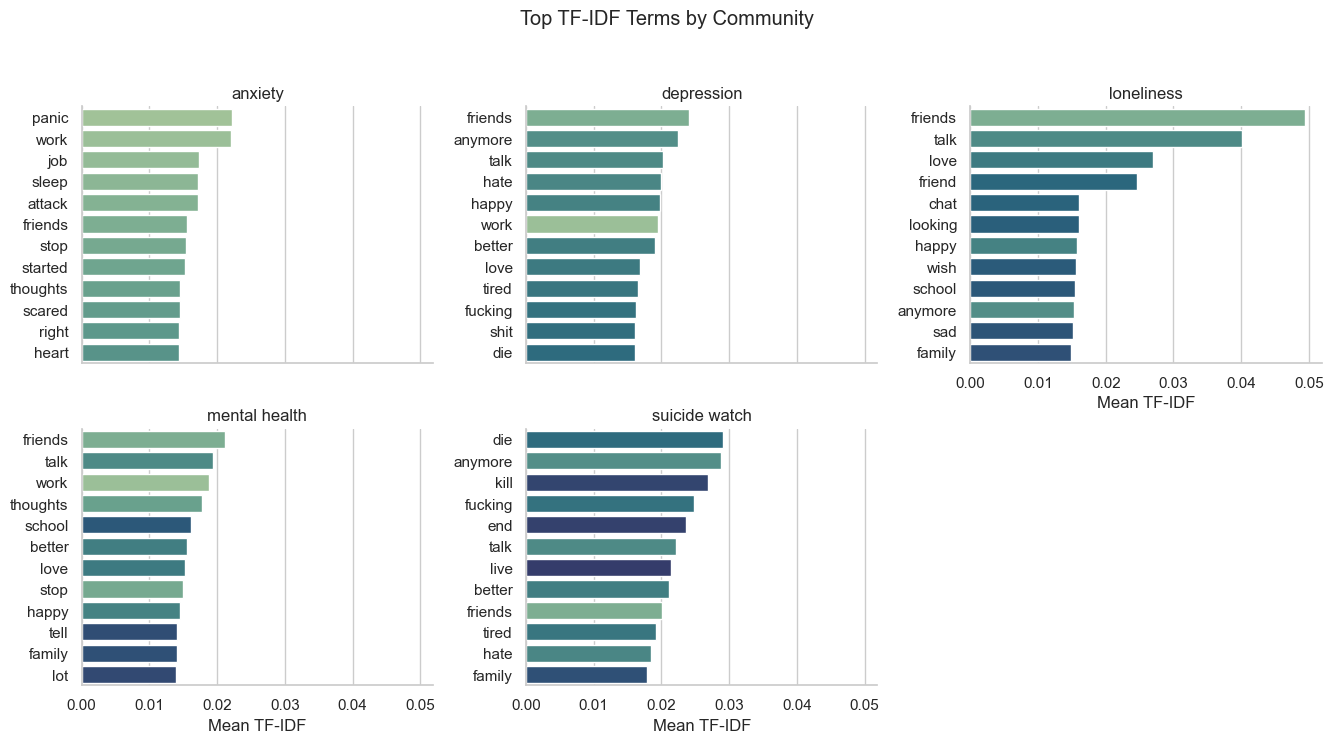

In [21]:
g = sns.catplot(
    data=top_terms, x="tfidf", y="term", col="factor", col_wrap=3,
    kind="bar", sharey=False, height=3.6, aspect=1.25, palette="crest"
)
g.set_titles("{col_name}")
g.set_axis_labels("Mean TF-IDF", "")
g.fig.suptitle("Top TF-IDF Terms by Community", y=1.03)
plt.tight_layout()

## 7. Machine Learning: Community Classification

The supervised task predicts the community from post text. This is not a diagnostic model; it tests whether language patterns are distinctive enough to separate the five Reddit communities.

To avoid inflated scores from class imbalance, the training data is capped to the same maximum number of posts per class and evaluated with a stratified holdout split.

In [22]:
model_df = (
    df.groupby("factor", group_keys=False)
      .apply(lambda x: x.sample(min(len(x), MODEL_ROWS_PER_CLASS), random_state=RANDOM_STATE))
      .sample(frac=1, random_state=RANDOM_STATE)
)
model_df["text"] = model_df["raw_text"].map(clean_text)
model_df = model_df[model_df["text"].str.len() >= 30].drop_duplicates(["text", "factor"])

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    model_df["text"], model_df["factor"],
    test_size=0.2, random_state=RANDOM_STATE, stratify=model_df["factor"]
)

In [24]:
def word_tfidf(max_features):
    return TfidfVectorizer(stop_words=STOPWORDS, token_pattern=TOKEN_PATTERN,
                           ngram_range=(1, 2), min_df=4, max_df=0.82,
                           max_features=max_features, sublinear_tf=True)

char_tfidf = TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5),
                             min_df=4, max_features=12_000, sublinear_tf=True)

In [25]:
models = {
    "NB word TF-IDF": make_pipeline(word_tfidf(12_000), MultinomialNB(alpha=0.15)),
    "LinearSVC word TF-IDF": make_pipeline(
        word_tfidf(15_000), LinearSVC(C=0.8, class_weight="balanced", random_state=RANDOM_STATE)
    ),
    "LinearSVC word+char": make_pipeline(
        FeatureUnion([("word", word_tfidf(12_000)), ("char", char_tfidf)]),
        LinearSVC(C=0.6, class_weight="balanced", random_state=RANDOM_STATE),
    ),
}

In [26]:
def score_model(name, pipe):
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, pred, average="macro", zero_division=0)
    fitted[name] = (pipe, pred)
    return {"model": name, "accuracy": accuracy_score(y_test, pred),
            "macro_precision": precision, "macro_recall": recall, "macro_f1": f1}

fitted = {}
results = pd.DataFrame(score_model(name, pipe) for name, pipe in models.items())
results = results.sort_values("macro_f1", ascending=False).round(3)
results

,model,accuracy,macro_precision,macro_recall,macro_f1
2,LinearSVC word+char,0.588,0.581,0.587,0.584
0,NB word TF-IDF,0.528,0.519,0.527,0.522
1,LinearSVC word TF-IDF,0.521,0.514,0.520,0.516


In [27]:
best_model = results.iloc[0]["model"]
best_pipe, best_pred = fitted[best_model]

report = pd.DataFrame(classification_report(y_test, best_pred, output_dict=True)).T.round(3)
report.loc[FACTOR_ORDER + ["accuracy", "macro avg", "weighted avg"]]

,precision,recall,f1-score,support
anxiety,0.727,0.757,0.742,497.000
depression,0.422,0.373,0.396,482.000
loneliness,0.690,0.742,0.715,488.000
mental health,0.510,0.513,0.512,493.000
suicide watch,0.558,0.552,0.555,487.000
accuracy,0.588,0.588,0.588,0.588
macro avg,0.581,0.587,0.584,2447.000
weighted avg,0.582,0.588,0.585,2447.000


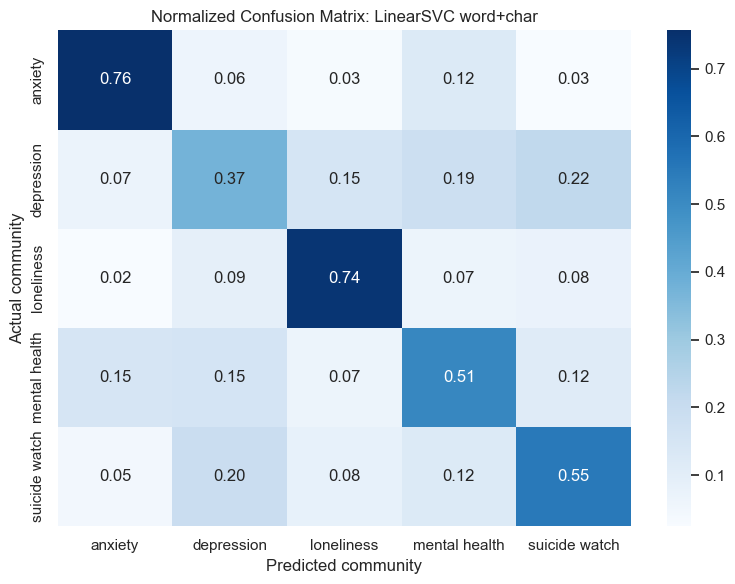

In [28]:
cm = confusion_matrix(y_test, best_pred, labels=FACTOR_ORDER, normalize="true")
cm_df = pd.DataFrame(cm, index=FACTOR_ORDER, columns=FACTOR_ORDER)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt=".2f", cmap="Blues")
plt.title(f"Normalized Confusion Matrix: {best_model}")
plt.xlabel("Predicted community")
plt.ylabel("Actual community")
plt.tight_layout()

### Depression Class Check

Depression is the weakest class in the classifier, so I briefly check where those posts are being confused and which terms are most distinctive.

In [29]:
depression_f1 = report.loc["depression", "f1-score"]
depression_overlap = cm_df.loc["depression"].drop("depression").sort_values(ascending=False).head(2)
depression_terms = top_terms.loc[top_terms["factor"].eq("depression"), "term"].head(8).tolist()

print(f"Depression F1: {depression_f1:.3f}")
print("Largest normalized confusions:")
for factor, value in depression_overlap.items():
    print(f"- {factor}: {value:.2f}")
print("Top depression TF-IDF terms:", ", ".join(depression_terms))

Depression F1: 0.396
Largest normalized confusions:
- suicide watch: 0.22
- mental health: 0.19
Top depression TF-IDF terms: friends, anymore, talk, hate, happy, work, better, love


Depression posts often use broad distress language that also appears in SuicideWatch, anxiety, and general mental-health discussions. The lower F1 score is therefore less surprising: the class boundary is semantically softer than loneliness, whose relationship and isolation vocabulary is more distinctive.

## 8. Key Findings

The final findings are generated from the cleaned data and model outputs rather than typed manually, which keeps this notebook reproducible.

In [30]:
most_active_factor = posts_by_factor.idxmax()
most_active_year = df["year"].value_counts().idxmax()
most_negative = sentiment_factor.idxmin()
best_accuracy = results.iloc[0]["accuracy"]
best_score = results.iloc[0]["macro_f1"]

In [31]:
findings = [
    f"The analysis dataset contains {len(df):,} usable posts loaded from {len(csv_files):,} raw CSV files.",
    f"{most_active_factor.title()} is the largest community in this dataset; {most_active_year} has the highest post volume.",
    f"{most_negative.title()} has the lowest average VADER sentiment in the NLP sample.",
    f"The best classifier is {best_model} with accuracy = {best_accuracy:.3f} and macro F1 = {best_score:.3f}.",
    f"Depression remains the hardest class to separate (F1 = {depression_f1:.3f}) because its language overlaps with nearby distress communities.",
    "TF-IDF terms reveal different discussion contexts across communities, including relationships, work/school stress, isolation, medication, and immediate distress language.",
]

for item in findings:
    print(f"- {item}")

- The analysis dataset contains 213,838 usable posts loaded from 219 raw CSV files.
- Mental Health is the largest community in this dataset; 2019 has the highest post volume.
- Suicide Watch has the lowest average VADER sentiment in the NLP sample.
- The best classifier is LinearSVC word+char with accuracy = 0.588 and macro F1 = 0.584.
- Depression remains the hardest class to separate (F1 = 0.396) because its language overlaps with nearby distress communities.
- TF-IDF terms reveal different discussion contexts across communities, including relationships, work/school stress, isolation, medication, and immediate distress language.


## 9. Conclusion

This rebuilt analysis keeps the original project story but uses a cleaner workflow: full-data coverage for trends, reproducible samples for heavier NLP, concise visualizations, interpretable TF-IDF terms, and a small supervised model comparison with proper train/test evaluation.

The results suggest that Reddit mental-health communities share broadly negative emotional language, but differ in their dominant contexts and vocabulary. The community-classification model shows moderate separation between subreddits, with depression harder to classify because its language overlaps with several nearby support communities. This should be interpreted as a language-pattern exercise, not as a diagnostic tool.